In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import seaborn.objects as so
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error

## Задача 1

1. Генерирайте фиксиран тестов комплект от данни $\mathbf{X_{test}}$ с N=1000 наблюдения, които следват истинската функция $f(\mathbf{X}) = X_1^2 + 6X_1 + 3X_2$ като предположите грешка $\epsilon \sim \mathcal{N}(0, 2)$.
2. Генерирайте К=50 извадки от същата функция $\mathbf{X_{train}}$ с N=200 наблюдения.
3. Тренирайте линейна регресия върху всяка от извадките и пресметнете $\hat{\mathbf{Y}}$ за тестовия комплект $\mathbf{X_{test}}$.
4. Tренирайте полиномна регресия от 2-ри, 4-ти и 6-ти ред върху всяка от извадките и пресметнете $\hat{\mathbf{Y}}$ за тестовия комплект $\mathbf{X_{test}}$.
5. Пресметнете системната грешка (Bias), вариацията на модела (Variance) и неотстранимата грешка (Irreducible error). Използвайте формулата:

$
   \quad \quad \mathbb{E}[(\mathbf{Y} - \mathbf{\hat{Y}})^2] = (f(\mathbf{X}) - \mathbb{E}[{\hat{f}(\mathbf{X})}])^2 + \operatorname{Var}[\hat{f}(\mathbf{X})] + \sigma^2
$

6. Визуализирайте резултатие с `barplot` диаграма за изобразяване на трите компонента на квадратираното отклонение за всеки от моделите.

In [140]:
def true_function(X1, X2):
    return (X1**2) + 10*X1 + 3*X2

def plot_bias_variance_decomposition(ax, N_train):
    # 1. Генериране на фиксиран тестов комплект
    N_test = 1000
    X1_test = np.random.uniform(-3, 3, N_test)
    X2_test = np.random.uniform(-3, 3, N_test)
    X_test = np.column_stack((X1_test, X2_test))
    f_test = true_function(X1_test, X2_test)
    sigma = 1.5

    # 2. Генериране на извадки
    K = 100
    X1_samples = np.random.uniform(-3, 3, (K, N_train))
    X2_samples = np.random.uniform(-3, 3, (K, N_train))
    X_samples = np.stack((X1_samples, X2_samples), axis=-1)
    f_samples = true_function(X1_samples, X2_samples)
    Y_samples = f_samples + np.random.normal(0, sigma, (K, N_train))

    # 3. и 4. Обучение и оценка на моделите

    # Първо дефинираме всички видове модели
    models = {
        'lin_reg': LinearRegression(),
        'poly2': make_pipeline(PolynomialFeatures(2), LinearRegression()),
        'poly4': make_pipeline(PolynomialFeatures(4), LinearRegression()),
        'poly6': make_pipeline(PolynomialFeatures(6), LinearRegression()),
    }


    # Приготвяме дикт за съхранение на резултатите от различните модели
    results = pd.DataFrame({ name: {} for name in models.keys() }, columns=['Model', 'Bias', 'Variance', 'Irreducible Error'], index=models.keys(), dtype=float)
    results['Model'] = results.index

    # Тренираме всеки от моделите
    for model_name, model in models.items():
        # Приготвяме (K, N_test) array за оценка на тестовия комплект
        Y_hat = np.zeros((K, N_test))

        # Тренираме на всяка извадка
        for k in range(K):
            X_train = X_samples[k]
            y_train = Y_samples[k]
            model.fit(X_train, y_train)
            Y_hat[k] = model.predict(X_test)

        # 5. Оценка на компоненти на квадратното отклонение
        bias = np.mean((f_test - np.mean(Y_hat, axis=0))**2)

        variance = np.var(Y_hat, axis=0)
        variance = np.mean(np.var(Y_hat, axis=0))

        irr_error = sigma**2

        # Запазваме резултатите за текущия модел
        results.loc[model_name, 'Bias'] = float(np.sqrt(bias))
        results.loc[model_name, 'Variance'] = float(variance)
        results.loc[model_name, '$\\sigma^2$'] = float(irr_error)

    # 6. Визуализация с наслоена стълбовидна диаграма
    barplot_data = (
        results
            .reset_index(drop=True)
            .melt(id_vars='Model', value_vars=['Bias', 'Variance', '$\\sigma^2$'], var_name='Metric', value_name='Value')
    )

    fig = sb.barplot(data=barplot_data, x='Model', y='Value', hue='Metric', palette='viridis', ax=ax)
    fig.set_ylabel('')
    fig.set_title(f'N_train = {N_train}')
    for container in fig.containers:
        fig.bar_label(container, fontsize=8, fmt='%.2f');

    return ax

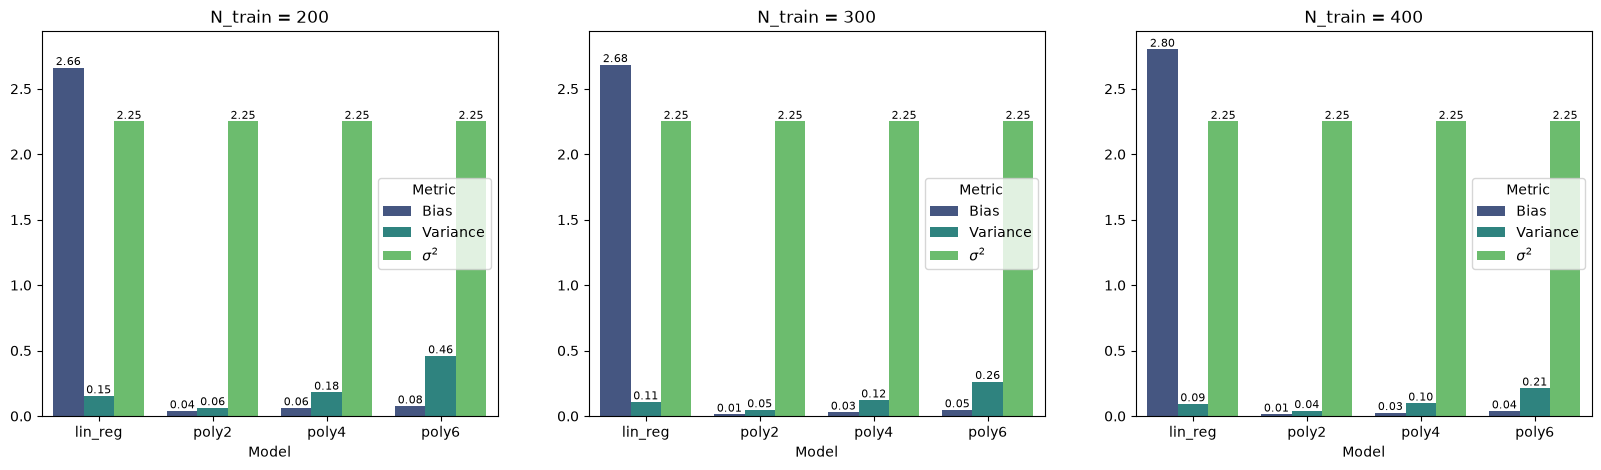

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ax1 = plot_bias_variance_decomposition(axes[0], N_train=200)
ax2 = plot_bias_variance_decomposition(axes[1], N_train=300)
ax3 = plot_bias_variance_decomposition(axes[2], N_train=400)
ylim = np.max([ ax.get_ylim()[1] for ax in [ax1, ax2, ax3]])
for ax in axes:
    ax.set_ylim(0, ylim)

## Задача 2

1. Генерирайте К=100 извадки от данни с N=200 наблюдения, които следват истинската функция $f(\mathbf{X}) = X_1^2 + 3X_2$ като предположите грешка $\epsilon \sim \mathcal{N}(0, 3)$.
2. Разделете всяка извадка наполовина, на тренировъчни и тест данни.
2. Пресмете RMSE метриката спрямо истинската функция за всяко К върху тестовия комплект. Запазете средната стойност на RMSE метриката на истинската функция.
3. Тренирайте линейна регресия върху тренировъчните данни и пресметнете RMSE метриката за всяко К върху тестовия комплект. Запазете RMSE метриките.
4. Тренирайте полиномна регресия oт 2-ри, 4-ти и 6-ти ред върху тренировъчните данни и пресметенете RMSE метриката за всяко К. Запазете RMSE метриките.
5. Визуализирайте RMSE метриките на моделите, и отбележете средната RMSE стойност на истинската функция.
6. Повторете целия експеримент с N=200, N=400, N=600 и N=800. Обяснете какво наблюдавате.

In [ ]:
def true_function(X1, X2):
    return 0.5*X1**2 + 3*X2

def plot_rmse_bias_variance(ax, N_train):
    N = N_train*2
    num_samples = 100
    sigma = 3.0

    # Генериране на 5-те извадки от данни
    samples = []
    for _ in range(num_samples):
        X1 = np.random.uniform(-3, 3, N)
        X2 = np.random.uniform(-3, 3, N)
        X = np.column_stack((X1, X2))

        # Истинска функция: f(X) = 0.5*X1^2 + 3*X2
        f_true = true_function(X1, X2)
        eps = np.random.normal(0, sigma, N)
        y_true = f_true + eps

        X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.5, random_state=42)

        samples.append((X_train, X_test, y_train, y_test))

    # Пресмятане на средното RMSE на истинската функция
    rmse_true = []
    for X_train, X_test, y_train, y_test in samples:
        y_test_pred = true_function(X_test[:, 0], X_test[:, 1])
        rmse_true.append(root_mean_squared_error(y_test, y_test_pred))

    mean_rmse_true = np.mean(rmse_true)

    # Приготвяме линеен модел и полиномни модели с степени 2, 3 и 4
    models = {
        "linear": LinearRegression(),
        "poly2": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
        "poly4": make_pipeline(PolynomialFeatures(degree=4), LinearRegression()),
        "poly6": make_pipeline(PolynomialFeatures(degree=6), LinearRegression()),
    }

    # Пресмятаме RMSE за всеки модел
    rmse_models = {name: [] for name in models}

    for X_train, X_test, y_train, y_test in samples:
        for name, model in models.items():
            model.fit(X_train, y_train)
            y_test_pred = model.predict(X_test)
            rmse = root_mean_squared_error(y_test, y_test_pred)
            rmse_models[name].append(rmse)


    y_positions = [1, 2, 3, 4]

    ax.boxplot(rmse_models["linear"], positions=[y_positions[0]])
    ax.boxplot(rmse_models["poly2"], positions=[y_positions[1]])
    ax.boxplot(rmse_models["poly4"], positions=[y_positions[2]])
    ax.boxplot(rmse_models["poly6"], positions=[y_positions[3]])
    ax.axhline(mean_rmse_true, color='red', linestyle='--', label='Средно RMSE на истинската функция')

    ax.legend()
    ax.set_ylabel("RMSE")
    ax.set_xticks(y_positions)
    ax.set_xticklabels(["Линеен модел", "Полином 2-ри ред", "Полином 4-ти ред", "Полином 6-ти ред"])
    ax.tick_params("x", rotation=45, rotation_mode="xtick")
    ax.set_title(f"N_train = {N_train}")

    return ax

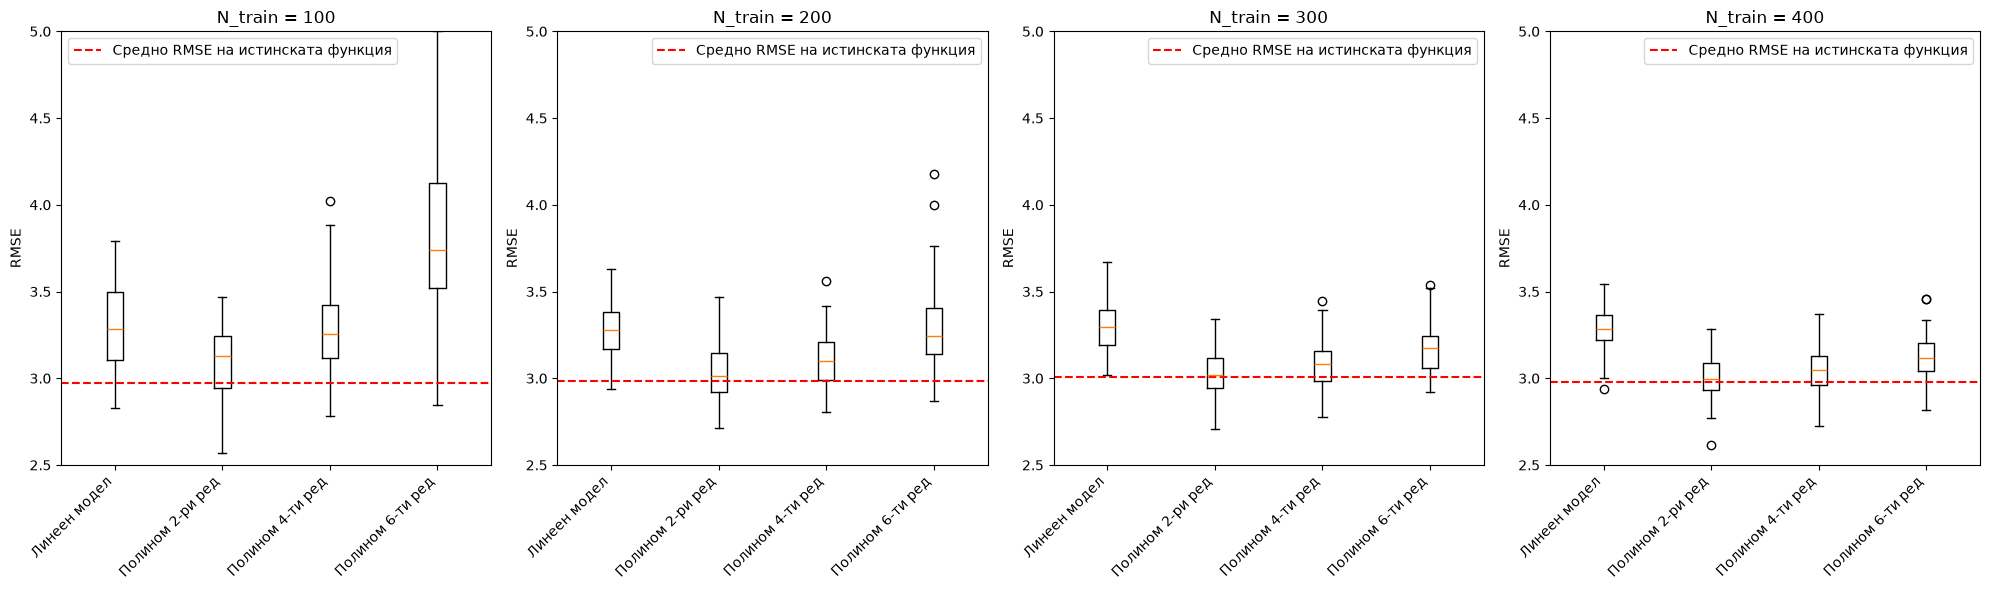

In [79]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
ax1 = plot_rmse_bias_variance(axes[0], N_train=100)
ax2 = plot_rmse_bias_variance(axes[1], N_train=200)
ax3 = plot_rmse_bias_variance(axes[2], N_train=300)
ax4 = plot_rmse_bias_variance(axes[3], N_train=400)
for ax in axes:
    ax.set_ylim(2.5, 5)
plt.tight_layout()
plt.show()